In [1]:
%load_ext autoreload
%autoreload 2
import sys
sys.path.insert(0, "..")
from main import FirnModel
import numpy as np
import matplotlib.pyplot as plt
import hvplot.xarray  

*** Starting setup.
*** Setup complete.
*** Starting integration.
*** Successfully finished integration in  0.158 seconds.
*** Post-processing.
**** interpolating onto regular vertical grids


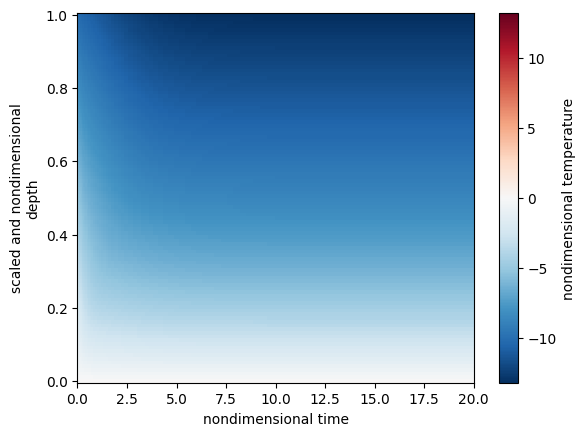

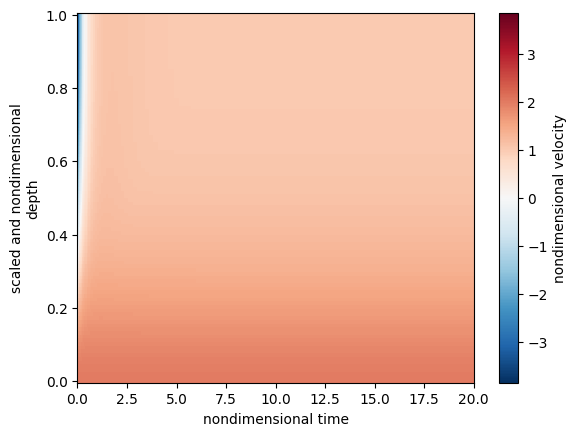

np.float64(0.0007674234368721415)

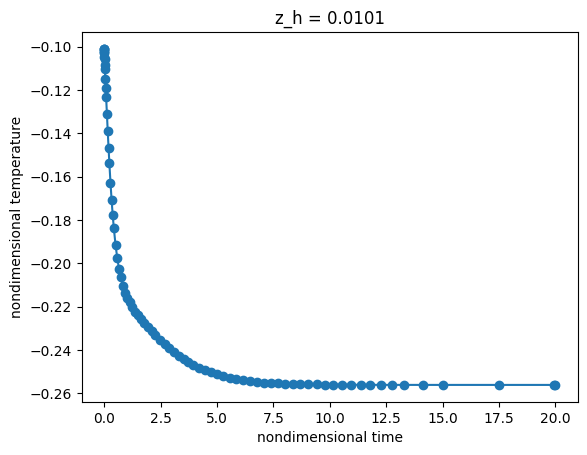

In [112]:
F = FirnModel().setup(method = 'BDF', interp_on_reg_z=True, simDuration=20).run()
F.T.plot()
plt.show()
F.w.plot()
plt.show()

F.T.isel(z_h=1).plot(marker='o')

F.attrs['simulation_parameters']['tau']

*** Starting setup.
*** Setup complete.
*** Starting integration.
*** Successfully finished integration in  2.07 seconds.
*** Post-processing.
**** interpolating onto regular vertical grids


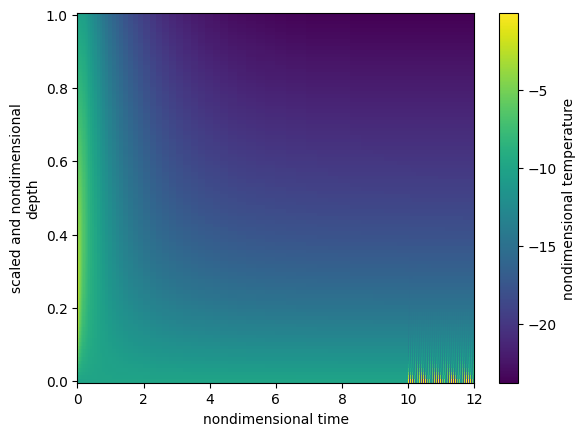

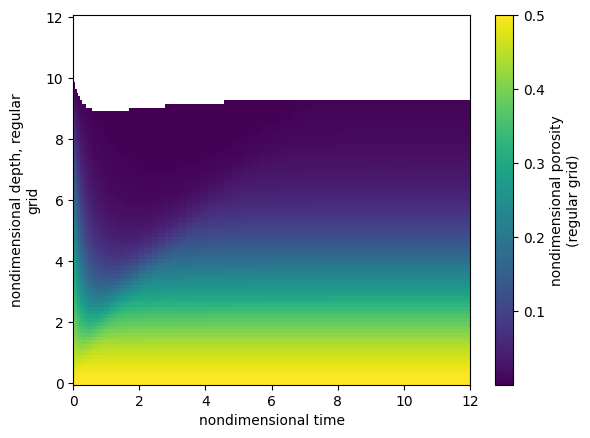

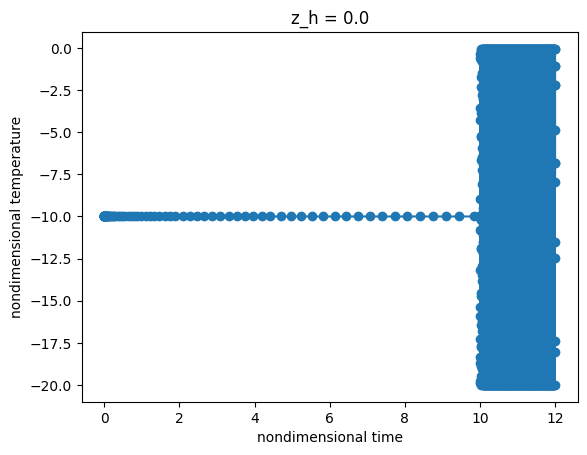

np.float64(0.0007674234368721415)

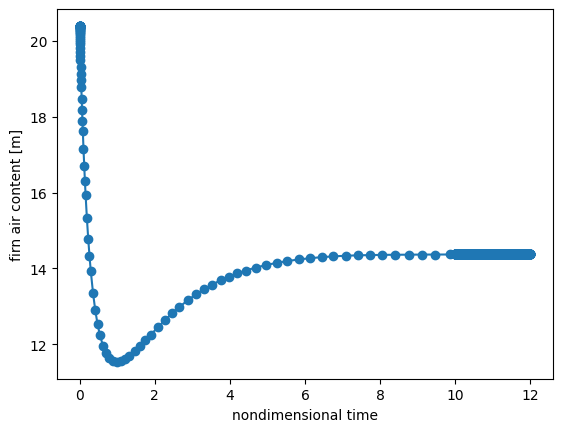

In [148]:
def Tsurf(t):
    t_0 = F.attrs['simulation_parameters']['t_0']
    t_0_years = t_0/(60*60*24*365.25)
    
    P = 1/t_0_years
    if t>10:   
        return -10 + 10*np.sin(2*np.pi*t/P)
    return -10
F = FirnModel().setup(method = 'BDF', interp_on_reg_z=True, simDuration=12, Tsurf=Tsurf).run()
F.T.plot()
plt.show()
F.phi_r.plot()
plt.show()

F.T.isel(z_h=0).plot(marker='o')
plt.show()
F.FAC.plot(marker='o')

F.attrs['simulation_parameters']['tau']

In [149]:
F.T.hvplot.line(x='z_h', ylim = (-24,0))


BokehModel(combine_events=True, render_bundle={'docs_json': {'d5c55159-f55f-4bc3-aa99-d4def176bef6': {'version…

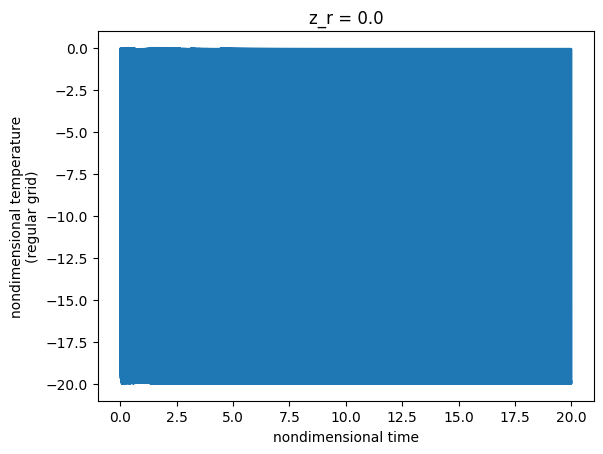

In [139]:
F.T_r.isel(z_r=0).plot()

In [151]:
F.nbytes/1e6

18.181128

In [ ]:
F.attrs['simulation_parameters']['tau'], F.attrs['simulation_parameters']['z_0']


(np.float64(0.0007674234368721415), np.float64(8.15947620785567))

In [132]:
# display scales

def disp(parameter):
    print(f"{parameter}: {F.attrs['simulation_parameters'][parameter]}")

disp('tau')
disp('z_0')
disp('T_0')
disp('T_avg')
disp('G')
disp('lambda_c')
disp('lambda_g')
disp('G')
disp('Pe')
2573172416.9093637/(60*60*24*365.0)


tau: 0.0007674234368721415
z_0: 8.15947620785567
T_0: 0.19427324304418261
T_avg: 253.15
G: 0.05
lambda_c: 28.521495581663814
lambda_g: 19.96504690716467
G: 0.05
Pe: 0.02272265092358894


81.59476207855668

In [133]:
F.attrs['simulation_parameters']['t_0']

np.float64(2573172416.9093637)

In [47]:
K = T
K_stag = 0.5 * (K[1:] + K[:-1])

In [48]:
K_stag[1:], K_stag[:-1]

(array([1.5, 2.5, 3.5, 4.5, 5.5, 6.5, 7.5, 8.5]),
 array([0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5, 7.5]))

In [49]:
K_stag

array([0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5, 7.5, 8.5])

In [2]:
T = np.arange(0,10)

d = (T[2:] - 2*T[1:-1] + T[:-2]) 
len(d), len(T)


(8, 10)

In [50]:
K_stag[1:]*T[2:] - (K_stag[1:] + K_stag[:-1])*T[1:-1] + K_stag[:-1]*T[:-2]

array([1., 1., 1., 1., 1., 1., 1., 1.])

In [3]:
T[1:]

array([1, 2, 3, 4, 5, 6, 7, 8, 9])

In [5]:
T[:-1]

array([0, 1, 2, 3, 4, 5, 6, 7, 8])

In [18]:
T[2:], T[1:-1], T[:-2]

(array([2, 3, 4, 5, 6, 7, 8, 9]),
 array([1, 2, 3, 4, 5, 6, 7, 8]),
 array([0, 1, 2, 3, 4, 5, 6, 7]))

In [126]:
(T[1:] - T[:-1])/0.01

array([1.01010101, 1.01010101, 1.01010101, 1.01010101, 1.01010101,
       1.01010101, 1.01010101, 1.01010101, 1.01010101, 1.01010101,
       1.01010101, 1.01010101, 1.01010101, 1.01010101, 1.01010101,
       1.01010101, 1.01010101, 1.01010101, 1.01010101, 1.01010101,
       1.01010101, 1.01010101, 1.01010101, 1.01010101, 1.01010101,
       1.01010101, 1.01010101, 1.01010101, 1.01010101, 1.01010101,
       1.01010101, 1.01010101, 1.01010101, 1.01010101, 1.01010101,
       1.01010101, 1.01010101, 1.01010101, 1.01010101, 1.01010101,
       1.01010101, 1.01010101, 1.01010101, 1.01010101, 1.01010101,
       1.01010101, 1.01010101, 1.01010101, 1.01010101, 1.01010101,
       1.01010101, 1.01010101, 1.01010101, 1.01010101, 1.01010101,
       1.01010101, 1.01010101, 1.01010101, 1.01010101, 1.01010101,
       1.01010101, 1.01010101, 1.01010101, 1.01010101, 1.01010101,
       1.01010101, 1.01010101, 1.01010101, 1.01010101, 1.01010101,
       1.01010101, 1.01010101, 1.01010101, 1.01010101, 1.01010